In [146]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

In [77]:
f =  '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Courses_Workshops/Water Resources Management/DateStorage.txt'
data = pd.read_table(f, header=0 , names=['Date', 'Storage'], parse_dates=['Date'])
g = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Courses_Workshops/Water Resources Management/Prec.txt'
prec = pd.read_table(g, header=0 , names=['Date', 'Greer', 'Eric'], parse_dates=['Date'])
data.set_index('Date', inplace=True)
h = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Courses_Workshops/Water Resources Management/Q_paila'
q = pd.read_table(h, header=0 , names=['Date', 'Q_paila'], parse_dates=['Date'], index_col='Date')

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_58919/4227506112.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_table(f, header=0 , names=['Date', 'Storage'], parse_dates=['Date'])
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_58919/4227506112.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  prec = pd.read_table(g, header=0 , names=['Date', 'Greer', 'Eric'], parse_dates=['Date'])


In [78]:
daily_storage = data.resample('D').mean()
#fill missing values with linear interpolation
daily_storage['Storage'] = daily_storage['Storage'].interpolate(method='linear')

In [79]:
q_monthly = q.resample('M').mean()
q_monthly['Q_paila'] = q_monthly['Q_paila'].interpolate(method='linear')


/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_58919/199165417.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  q_monthly = q.resample('M').mean()


<Axes: title={'center': 'Monthly Average Discharge at La Paila gage'}, xlabel='Date', ylabel='Streamflow (m3/s)'>

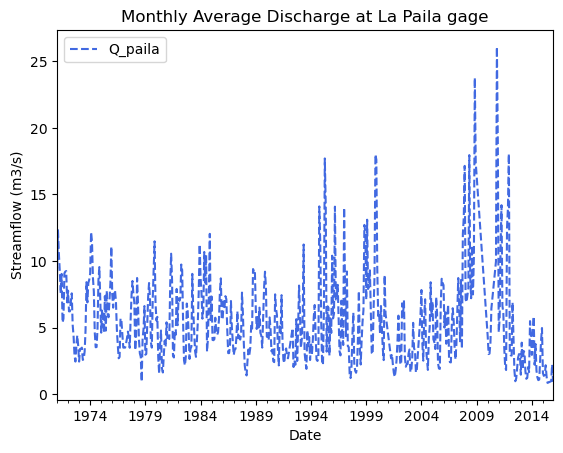

In [88]:
q_monthly.plot(title='Monthly Average Discharge at La Paila gage', ylabel='Streamflow (m3/s)', xlabel='Date', style='--', color='royalblue')

In [ ]:
daily_storage.plot(title='Daily Water Storage Over Time', ylabel='Storage (acre-feet)', xlabel='Date')
plt.grid()
prec.loc[:'2018'].plot(x='Date', y=['Greer', 'Eric'], title='Daily Precipitation Over Time', ylabel='Precipitation (units)', xlabel='Date')


In [7]:
# correlation between storage and precipitation
merged_data = daily_storage.join(prec.set_index('Date'), how='inner')
# standarize the data
merged_data = (merged_data - merged_data.mean()) / merged_data.std()

correlation_greer = merged_data['Storage'].corr(merged_data['Greer'])
correlation_eric = merged_data['Storage'].corr(merged_data['Eric'])
print(f'Correlation between Storage and Greer Precipitation: {correlation_greer}')
print(f'Correlation between Storage and Eric Precipitation: {correlation_eric}')

Correlation between Storage and Greer Precipitation: -0.02785622694517585
Correlation between Storage and Eric Precipitation: -0.04817354733024102


In [106]:
# Define SARIMA order: ARIMA(p,d,q) x (P,D,Q,s)
model = sm.tsa.statespace.SARIMAX(daily_storage,
                                  order=(10, 1, 1),
                                  seasonal_order=(1, 1, 1, 12),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

results = model.fit(disp=False)

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [203]:
# moving average model using statsmodels
ma = 36
ma_model = sm.tsa.statespace.SARIMAX(q_monthly,
                                        order=(0, 0, ma),
                                        seasonal_order=(0, 0, 0, 0),
                                        enforce_stationarity=False,
                                        enforce_invertibility=False)
ma_results = ma_model.fit(disp=False)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [204]:
ma_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Q_paila   No. Observations:                  540
Model:              SARIMAX(0, 0, 36)   Log Likelihood               -1195.145
Date:                Thu, 06 Nov 2025   AIC                           2464.290
Time:                        22:19:19   BIC                           2620.452
Sample:                    01-31-1971   HQIC                          2525.552
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.8480      0.097      8.699      0.000       0.657       1.039
ma.L2          0.3985      0.053      7.462      0.000       0.294       0.503
ma.L3          0.3908      0.060      6.540      0.000       0.274       0.508
ma.L4          0.4413      0.073      6.078      0.000       0.299       0.584
ma.L5          0.3625      0.071      5.073      0.000       0.222       0.503
ma.L6          0.6011      0.082      7.342      0.000       0.441       0.762
ma.L7          0.3988      0.073      5.482      0.000       0.256       0.541
ma.L8          0.4125      0.080      5.155      0.000       0.256       0.569
ma.L9          0.2100      0.080      2.639      0.008       0.054       0.366
ma.L10         0.3375      0.083      4.075      0.000       0.175       0.500
ma.L11         0.4091      0.087      4.721      0.000       0.239       0.579
ma.L12         0.4537      0.080      5.704      0.000       0.298       0.610
ma.L13         0.5903      0.088      6.717      0.000       0.418       0.762
ma.L14         0.2582      0.082      3.161      0.002       0.098       0.418
ma.L15         0.3472      0.089      3.922      0.000       0.174       0.521
ma.L16         0.2563      0.090      2.838      0.005       0.079       0.433
ma.L17         0.3848      0.092      4.179      0.000       0.204       0.565
ma.L18         0.3333      0.088      3.776      0.000       0.160       0.506
ma.L19         0.3192      0.090      3.531      0.000       0.142       0.496
ma.L20         0.2252      0.104      2.173      0.030       0.022       0.428
ma.L21         0.2144      0.106      2.015      0.044       0.006       0.423
ma.L22         0.2976      0.102      2.919      0.004       0.098       0.497
ma.L23         0.3155      0.106      2.973      0.003       0.108       0.524
ma.L24         0.3860      0.101      3.808      0.000       0.187       0.585
ma.L25         0.2784      0.106      2.628      0.009       0.071       0.486
ma.L26         0.1467      0.103      1.428      0.153      -0.055       0.348
ma.L27         0.2030      0.104      1.958      0.050      -0.000       0.406
ma.L28         0.1894      0.106      1.793      0.073      -0.018       0.396
ma.L29         0.2158      0.099      2.186      0.029       0.022       0.409
ma.L30         0.0988      0.092      1.076      0.282      -0.081       0.279
ma.L31         0.0667      0.088      0.760      0.447      -0.105       0.239
ma.L32         0.0315      0.081      0.391      0.695      -0.126       0.189
ma.L33         0.0074      0.084      0.087      0.930      -0.158       0.173
ma.L34         0.0216      0.071      0.305      0.760      -0.117       0.160
ma.L35         0.1603      0.071      2.252      0.024       0.021       0.300
ma.L36         0.1503      0.058      2.612      0.009       0.038       0.263
sigma2         5.5150      0.589      9.370      0.000       4.361       6.669
=================================================================================

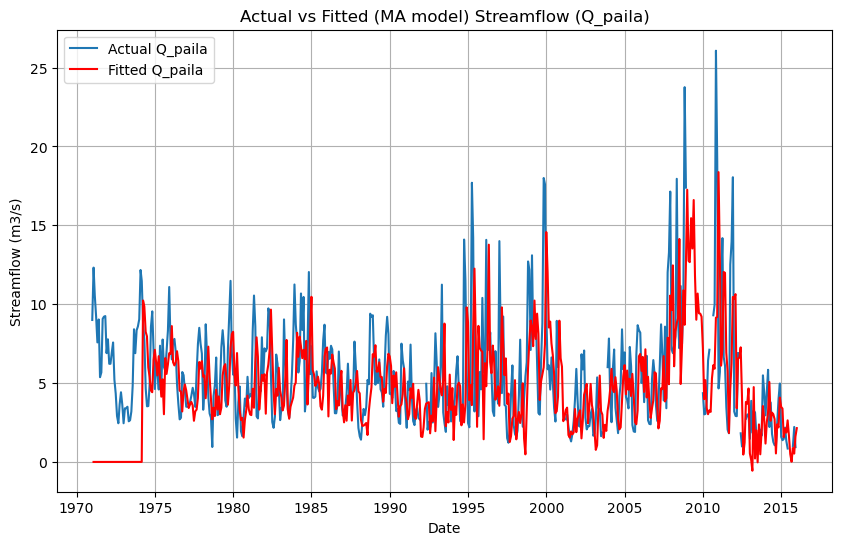

In [205]:
#rsults for ma model
plt.figure(figsize=(10, 6))
plt.plot(q, label='Actual Q_paila')
plt.plot(ma_results.fittedvalues, color='red', label='Fitted Q_paila')
plt.title('Actual vs Fitted (MA model) Streamflow (Q_paila)')
plt.xlabel('Date')
plt.ylabel('Streamflow (m3/s)')
plt.legend()
plt.grid()

In [206]:
# error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = np.sqrt(mean_squared_error(q_monthly[ma:], ma_results.fittedvalues[ma:]))
mae = mean_absolute_error(q_monthly[ma:], ma_results.fittedvalues[ma:])
nash = 1 - (sum((q_monthly[ma:]['Q_paila'] - ma_results.fittedvalues[ma:])**2) / sum((q_monthly['Q_paila'][ma:] - q_monthly['Q_paila'][ma:].mean())**2))
print(f'Root Mean Squared Error (MA model): {mse}')
print(f'Mean Absolute Error (MA model): {mae}')
print(f'Nash-Sutcliffe Efficiency (MA model): {nash}')


Root Mean Squared Error (MA model): 2.668024380183242
Mean Absolute Error (MA model): 1.8393840086123432
Nash-Sutcliffe Efficiency (MA model): 0.41996917577010917


In [63]:
# Define SARIMA order: ARIMA(p,d,q) x (P,D,Q,s)
model = sm.tsa.statespace.SARIMAX(q_monthly,
                                  order=(1, 1, 1),
                                  seasonal_order=(1, 1, 1, 12),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

results = model.fit(disp=False)

In [128]:
12*10

120

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            Q_paila   No. Observations:                  540
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1203.555
Date:                            Thu, 06 Nov 2025   AIC                           2417.111
Time:                                    15:37:32   BIC                           2438.312
Sample:                                01-31-1971   HQIC                          2425.421
                                     - 12-31-2015                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4563      0.051      8.910      0.000       0.356       0.557
ma.L1         -0.8864      0.030    -29.727      0.000      -0.945      -0.828
ar.S.L12      -0.0022      0.005     -0.465      0.642      -0.011       0.007
ma.S.L12      -0.9630      0.026    -37.344      0.000      -1.014      -0.912
sigma2         6.0815      0.201     30.245      0.000       5.687       6.476
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               923.45
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               2.69   Skew:                             1.20
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

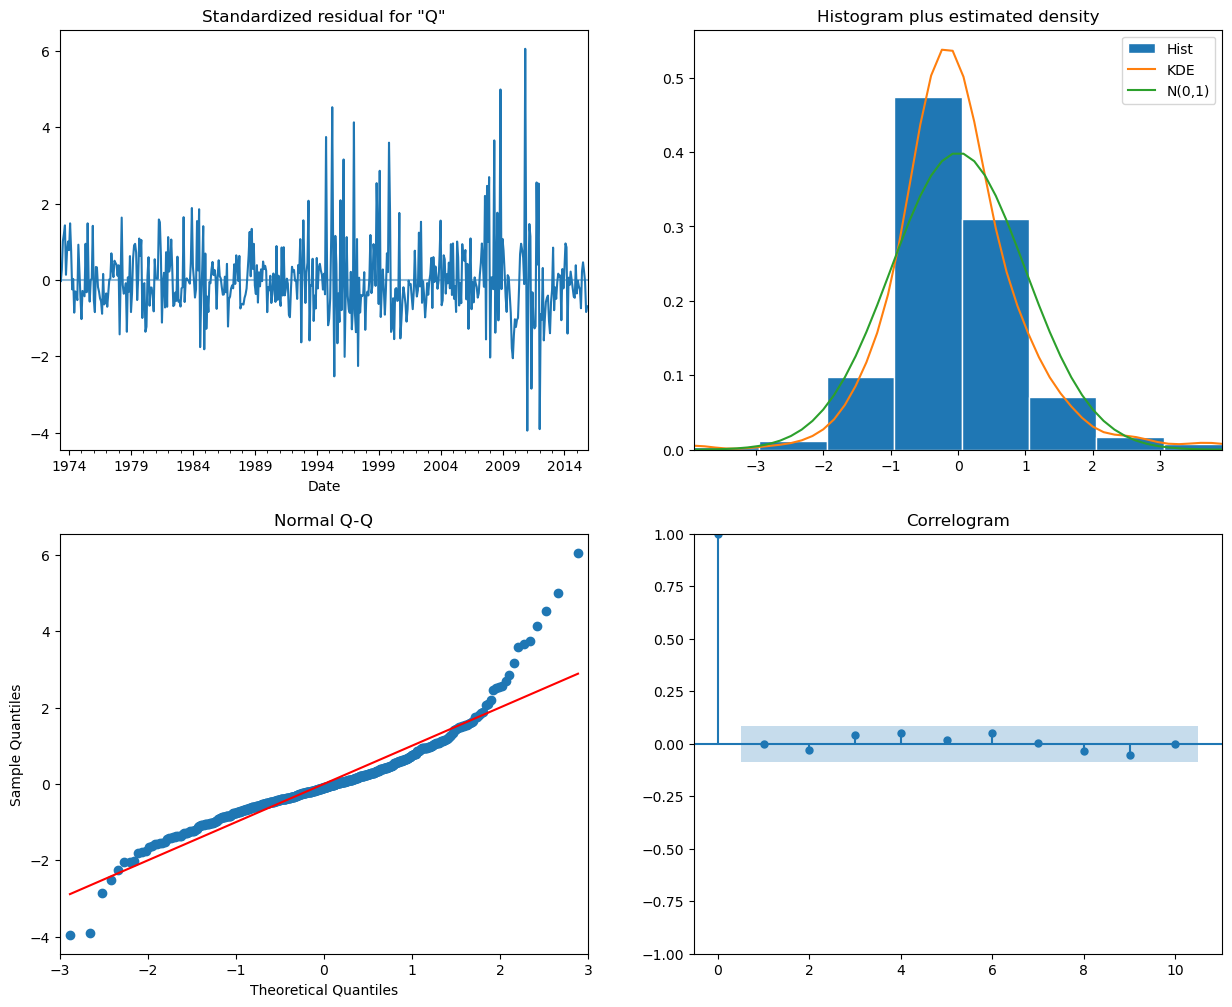

In [64]:
results.plot_diagnostics(figsize=(15, 12))
results.summary()

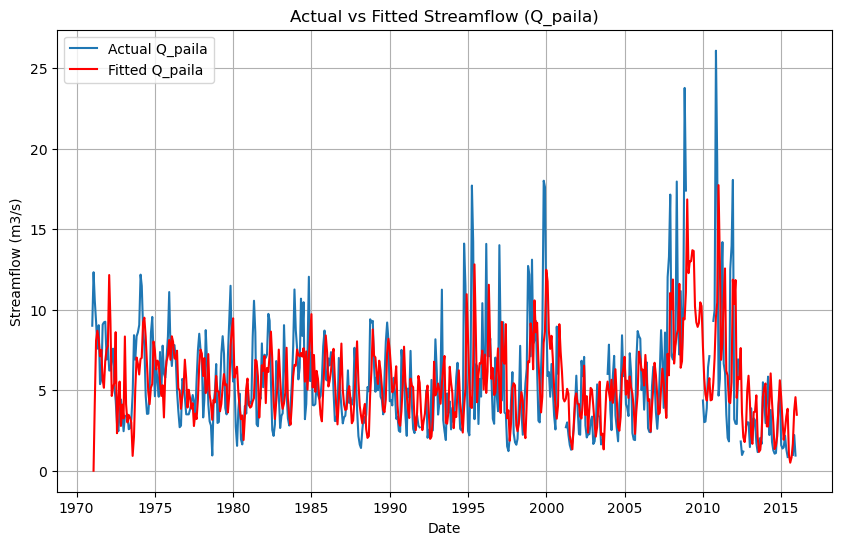

In [97]:
# plot model data vs actual data for q model
plt.figure(figsize=(10, 6))
plt.plot(q, label='Actual Q_paila')
plt.plot(results.fittedvalues, color='red', label='Fitted Q_paila')
plt.title('Actual vs Fitted Streamflow (Q_paila)')
plt.xlabel('Date')
plt.ylabel('Streamflow (m3/s)')
plt.legend()
plt.grid()



In [207]:
# error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(q_monthly, results.fittedvalues)
mae = mean_absolute_error(q_monthly, results.fittedvalues)
nash = 1 - (sum((q_monthly['Q_paila'] - results.fittedvalues) ** 2) / sum((q_monthly['Q_paila'] - q_monthly['Q_paila'].mean()) ** 2))
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Nash-Sutcliffe Efficiency: {nash}')



ValueError: Found input variables with inconsistent numbers of samples: [540, 1461]

In [70]:
# grid search for best SARIMA parameters
import itertools
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
best_aic = float("inf")
best_params = None
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            model = sm.tsa.statespace.SARIMAX(q_monthly,
                                              order=param,
                                              seasonal_order=param_seasonal,
                                              enforce_stationarity=False,
                                              enforce_invertibility=False)
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = (param, param_seasonal)
        except:
            continue
print(f'Best SARIMA parameters: {best_params} with AIC: {best_aic}')
# The best parameters found can be used to refit the model
model = sm.tsa.statespace.SARIMAX(q_monthly,
                                  order=best_params[0],
                                  seasonal_order=best_params[1],
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
results = model.fit(disp=False)


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/

Best SARIMA parameters: ((1, 0, 2), (1, 1, 2, 12)) with AIC: 2348.310778018167


In [209]:
model = sm.tsa.statespace.SARIMAX(q_monthly,
                                  order=best_params[0],
                                  seasonal_order=best_params[1],
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)
results = model.fit(disp=False)

Text(0.02, 0.95, 'Parameters: ((1, 0, 2), (1, 1, 2, 12))')

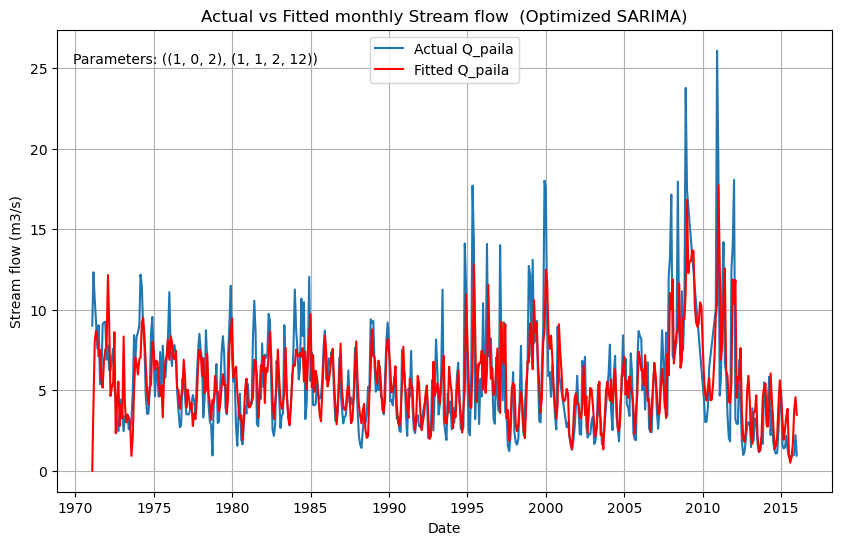

In [210]:
#plot fitted vs actual for q_monthloly
plt.figure(figsize=(10, 6))
plt.plot(q_monthly, label='Actual Q_paila')
plt.plot(results.fittedvalues, color='red', label='Fitted Q_paila')
plt.title('Actual vs Fitted monthly Stream flow  (Optimized SARIMA)')
plt.xlabel('Date')
plt.ylabel('Stream flow (m3/s)')
plt.legend()
plt.grid()
# show parameters
plt.text(0.02, 0.95, f'Parameters: {best_params}', transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top')


In [211]:
mse = np.sqrt(mean_squared_error(q_monthly, results.fittedvalues))
mae = mean_absolute_error(q_monthly, results.fittedvalues)
nash = 1 - (sum((q_monthly['Q_paila'] - results.fittedvalues) ** 2) / sum((q_monthly['Q_paila'] - q_monthly['Q_paila'].mean()) ** 2))
print(f'Root Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Nash-Sutcliffe Efficiency: {nash}')

Root Mean Squared Error: 2.507835173120989
Mean Absolute Error: 1.7135524227413457
Nash-Sutcliffe Efficiency: 0.4735222268002952


/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


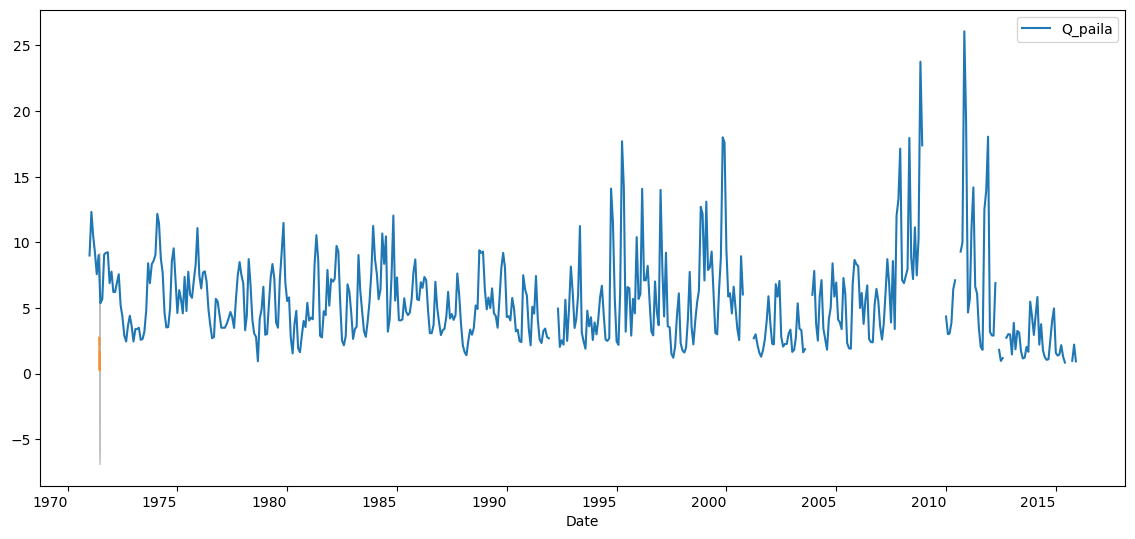

In [40]:
# forecast for next 12 months
pred_uc = results.get_forecast(steps=12)
pred_ci = pred_uc.conf_int()
ax = q.plot(label='Observed', figsize=(14, 7))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast', alpha=.7)
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)


In [69]:
pred_uc.predicted_mean

525    2.290867
526    2.764672
527    1.991092
528    0.323390
529    0.916694
530    0.904628
531    0.629283
532    1.652577
533    0.601064
534    0.682837
535    1.255044
536    0.252879
Name: predicted_mean, dtype: float64

                                      SARIMAX Results                                      
Dep. Variable:                             Storage   No. Observations:                 1461
Model:             SARIMAX(10, 1, 1)x(1, 1, 1, 30)   Log Likelihood              -10721.289
Date:                             Tue, 28 Oct 2025   AIC                          21470.577
Time:                                     02:42:28   BIC                          21543.896
Sample:                                 01-01-2015   HQIC                         21497.995
                                      - 12-31-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.9602      0.087     22.426      0.000       1.789       2.132
ar.L2         -1.2506      

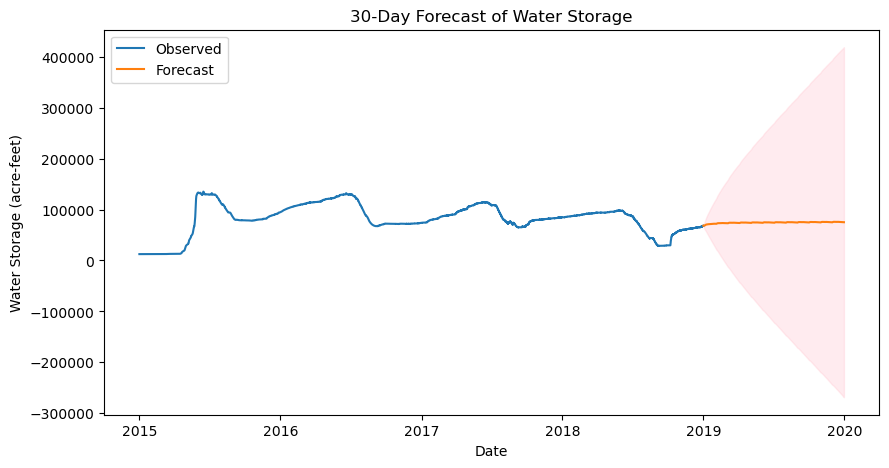

In [84]:
# Print model fit summary
print(results.summary())

# Forecast the next 30 days
forecast = results.get_forecast(steps=365)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot forecast
plt.figure(figsize=(10,5))
plt.plot(data.index, data['Storage'], label='Observed')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast')
plt.fill_between(forecast_mean.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Water Storage (acre-feet)')
plt.legend()
plt.title("30-Day Forecast of Water Storage")
plt.show()

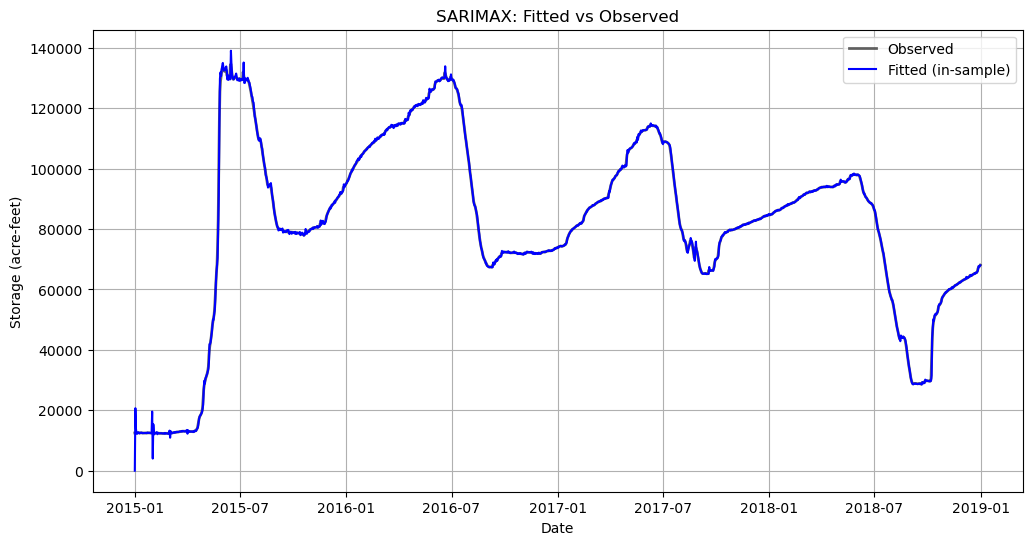

In [80]:
# Get model-predicted values over the training period
fitted_vals = results.predict(start=daily_storage.index[0], end=daily_storage.index[-1])

# Plot observed vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_storage.index, daily_storage['Storage'], label='Observed', color='black', alpha=0.6, linewidth=2)
plt.plot(fitted_vals.index, fitted_vals, label='Fitted (in-sample)', color='blue')
plt.title('SARIMAX: Fitted vs Observed')
plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Storage (acre-feet)')
plt.show()

In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_true = daily_storage['Storage']
y_pred = fitted_vals

rmse = mean_squared_error(y_true, y_pred)
#mae = mean_absolute_error(y_true, y_pred)
mape = (abs((y_true - y_pred) / y_true).mean()) * 100
nse = 1 - (sum((y_true - y_pred) ** 2) / sum((y_true - y_true.mean()) ** 2))

print(f"RMSE: {rmse:.2f}")
#print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"NSE: {nse:.2f}")

RMSE: 498181.72
MAPE: 0.57%
NSE: 1.00


In [40]:
daily_storage.isna().sum()

Storage    14
dtype: int64

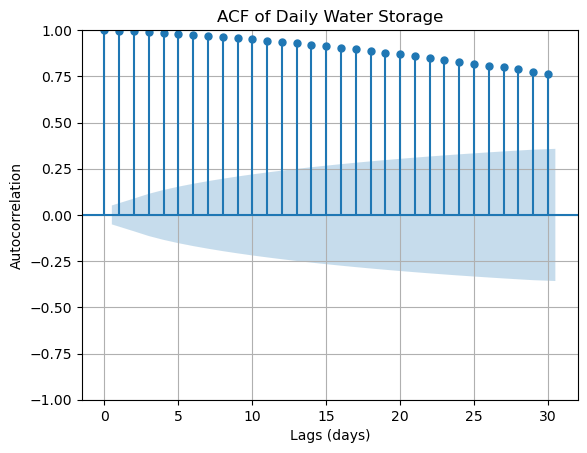

In [71]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Plot ACF up to 400 lags (more than a year of daily lags)
plot_acf(daily_storage.values, lags=30)
plt.title("ACF of Daily Water Storage")
plt.xlabel("Lags (days)")
plt.ylabel("Autocorrelation")
plt.grid()

plt.show()

In [59]:
daily_storage.values

array([[12516.66666667],
       [12540.        ],
       [12628.69565217],
       ...,
       [67558.33333333],
       [67802.08333333],
       [68067.44186047]], shape=(1461, 1))